In [1]:
# Cell 1: Imports
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, roc_auc_score, classification_report
)
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Masking
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
import random
from sklearn.utils import resample

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print(f"TensorFlow Version: {tf.__version__}")
print(f"Num GPUs Available: {len(tf.config.experimental.list_physical_devices('GPU'))}")

TensorFlow Version: 2.16.2
Num GPUs Available: 0


In [2]:
# Cell 2: Configuration
PROCESSED_DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'notebooks/steinmetz_data_downloads'))
print(f"Data will be loaded from: {PROCESSED_DATA_DIR}")

TARGET_BRAIN_REGION_X = 'VISp'

X_TIME_WINDOW_START_POST_EVENT_MS = 0 
X_TIME_WINDOW_END_POST_EVENT_MS = 500 

DECISION_LEFT = 1
DECISION_RIGHT = -1

N_EPOCHS = 100
BATCH_SIZE = 64
LSTM_UNITS_1 = 128
LSTM_UNITS_2 = 64
DENSE_UNITS_CLASS = 64
DROPOUT_RATE = 0.1
LEARNING_RATE = 0.00001 
N_SPLITS_CV = 5
EARLY_STOPPING_PATIENCE = 15

APPLY_UPSAMPLING_AGE = True

Data will be loaded from: /Volumes/SSD/IMPACT SCHOLAR SUBMISSION 1/neural_navigators-main/notebooks/steinmetz_data_downloads


In [3]:
# Cell 3: Data Loading
def load_steinmetz_npz_data(data_dir):
    alldat_list = []
    main_npz_files = [os.path.join(data_dir, f'steinmetz_part{j}.npz') for j in range(3)]
    print(f"Loading main data from {data_dir}:")
    for f_path in main_npz_files:
        f_name = os.path.basename(f_path)
        if not os.path.isfile(f_path): raise FileNotFoundError(f'{f_name} missing from {data_dir}.')
        print(f"  - Loading {f_name}...")
        try:
            data_part = np.load(f_path, allow_pickle=True)
            if 'dat' in data_part and isinstance(data_part['dat'], (list, np.ndarray)) and len(data_part['dat']) > 0 and isinstance(data_part['dat'][0], dict):
                alldat_list.extend(data_part['dat'])
            else: print(f"Warning: 'dat' in {f_name} not as expected.")
        except Exception as e: print(f"Error loading {f_name}: {e}"); raise
    if not alldat_list: raise ValueError("No main data loaded.")
    print(f"Loaded main data for {len(alldat_list)} sessions.")

    lfp_file_path = os.path.join(data_dir, 'steinmetz_lfp.npz')
    if not os.path.isfile(lfp_file_path): raise FileNotFoundError(f'steinmetz_lfp.npz not found in {data_dir}.')
    print(f"\nLoading LFP data from: {os.path.basename(lfp_file_path)}...")
    dat_LFP_list = []
    try:
        dat_LFP_all_sessions_raw = np.load(lfp_file_path, allow_pickle=True)['dat']
        if (isinstance(dat_LFP_all_sessions_raw, np.ndarray) and dat_LFP_all_sessions_raw.ndim == 1 and len(dat_LFP_all_sessions_raw) > 0 and isinstance(dat_LFP_all_sessions_raw[0], dict)) or \
           (isinstance(dat_LFP_all_sessions_raw, list) and len(dat_LFP_all_sessions_raw) > 0 and isinstance(dat_LFP_all_sessions_raw[0], dict)):
            dat_LFP_list = list(dat_LFP_all_sessions_raw)
        else: raise ValueError("'dat' in LFP not expected format.")
        print(f"Loaded LFP data for {len(dat_LFP_list)} sessions.")
    except Exception as e: raise ValueError(f"Error loading LFP: {e}")

    if len(alldat_list) != len(dat_LFP_list):
        print(f"Warning: Session count mismatch ({len(alldat_list)} vs {len(dat_LFP_list)}).")
        min_sessions = min(len(alldat_list), len(dat_LFP_list))
        if min_sessions == 0: raise ValueError("Zero sessions after alignment.")
        alldat_list, dat_LFP_list = alldat_list[:min_sessions], dat_LFP_list[:min_sessions]
        print(f"Adjusted to {min_sessions} sessions.")
    return alldat_list, dat_LFP_list

alldat, dat_LFP = load_steinmetz_npz_data(PROCESSED_DATA_DIR)

Loading main data from /Volumes/SSD/IMPACT SCHOLAR SUBMISSION 1/neural_navigators-main/notebooks/steinmetz_data_downloads:
  - Loading steinmetz_part0.npz...
  - Loading steinmetz_part1.npz...
  - Loading steinmetz_part2.npz...
Loaded main data for 39 sessions.

Loading LFP data from: steinmetz_lfp.npz...
Loaded LFP data for 39 sessions.


In [4]:
# Cell 4: Helper Function - Mouse Details
mouse_age_data = { 'Cori': 11, 'Forssmann': 26, 'Hench': 31, 'Lederberg': 15, 'Moniz': 30, 'Muller': 17, 'Radnitz': 20, 'Richards': 26, 'Tatum': 15, 'Theiler': 46 }
YOUNGER_THRESHOLD_WEEKS = 20
def get_mouse_details_by_session(session_idx, session_data_main):
    mouse_name = session_data_main.get('mouse_name', f"MouseUnknown_S{session_idx}")
    mouse_age_weeks = mouse_age_data.get(mouse_name)
    age_category = 'Unknown'
    if mouse_age_weeks is not None: age_category = 'Younger' if mouse_age_weeks <= YOUNGER_THRESHOLD_WEEKS else 'Older'
    return mouse_name, mouse_age_weeks, age_category

In [5]:
# Cell 5: Data Preprocessing for Decision Prediction (Corrected stim_onset handling)
all_X_data, all_Y_decision, all_session_ids, all_mouse_names, all_age_categories = [], [], [], [], []

print(f"Processing {len(alldat)} sessions for decision prediction...")
for session_idx in range(len(alldat)):
    session_data_main, session_data_lfp = alldat[session_idx], dat_LFP[session_idx]
    mouse_name, mouse_age, age_category = get_mouse_details_by_session(session_idx, session_data_main)
    if age_category == 'Unknown': continue
    
    print(f'\n--- Session {session_idx} ({mouse_name}, {age_category}) ---')
    if not all(k in session_data_lfp for k in ['lfp', 'brain_area_lfp']) or \
       not all(k in session_data_main for k in ['stim_onset', 'response', 'response_time', 'bin_size']):
        print(f'  Skipping: missing essential keys.'); continue

    lfp_all_ch, brain_areas, dt = session_data_lfp['lfp'], np.array(session_data_lfp['brain_area_lfp']), session_data_main['bin_size']
    if not isinstance(dt, (int, float)) or dt <= 0: print(f"  Skipping: invalid bin_size."); continue
    
    n_trials_lfp = lfp_all_ch.shape[1]
    responses_orig = session_data_main['response'] 
    response_times_orig = session_data_main['response_time']
    
    responses = np.asarray(responses_orig).squeeze()
    if responses.ndim == 0: responses = np.array([responses.item()])
    response_times = np.asarray(response_times_orig).squeeze()
    if response_times.ndim == 0: response_times = np.array([response_times.item()])
    
    n_trials_resp_val = len(responses)
    n_trials_resp_time = len(response_times)

    # --- Corrected stim_onset handling ---
    stim_onset_times_orig = session_data_main['stim_onset']
    event_times_for_X = np.asarray(stim_onset_times_orig).squeeze() # Handles both scalar and array
        
    if event_times_for_X.ndim > 1: # Should be 0D (scalar) or 1D (n_trials,)
        print(f'  Skipping session {session_idx}: stim_onset has unexpected shape {event_times_for_X.shape}'); continue
    
    event_source_for_X = "stim_onset" 
    # --- End of corrected stim_onset handling ---
    
    n_trials_session = min(n_trials_lfp, n_trials_resp_val, n_trials_resp_time)
    if event_times_for_X.ndim == 1: # If stim_onset was per-trial array
        n_trials_session = min(n_trials_session, len(event_times_for_X))
    
    if n_trials_session == 0: 
        print(f'  Skipping session {session_idx}: Zero common trials after initial length checks.')
        continue

    if lfp_all_ch.shape[1] != n_trials_session: lfp_all_ch = lfp_all_ch[:, :n_trials_session, :]
    if event_times_for_X.ndim == 1 and len(event_times_for_X) != n_trials_session: 
        event_times_for_X = event_times_for_X[:n_trials_session]
    if len(responses) != n_trials_session: responses = responses[:n_trials_session]
    if len(response_times) != n_trials_session: response_times = response_times[:n_trials_session]

    print(f"  Using {n_trials_session} trials for session {session_idx}, X aligned to {event_source_for_X}.")

    visp_idx = np.where(brain_areas == TARGET_BRAIN_REGION_X)[0]
    if len(visp_idx) == 0: print(f'  Skipping: {TARGET_BRAIN_REGION_X} not found.'); continue
    lfp_visp_trials = lfp_all_ch[visp_idx, :, :]

    x_start_s, x_end_s = X_TIME_WINDOW_START_POST_EVENT_MS/1000.0, X_TIME_WINDOW_END_POST_EVENT_MS/1000.0
    
    session_X_list, session_Y_decision_list = [], []
    
    for i in range(n_trials_session):
        current_response = responses[i]
        if current_response != DECISION_LEFT and current_response != DECISION_RIGHT:
            continue

        event_t_x = event_times_for_X if event_times_for_X.ndim == 0 else event_times_for_X[i]
        resp_t = response_times[i]
        if np.isnan(event_t_x) or np.isnan(resp_t): continue

        x_window_start_abs_s = event_t_x + x_start_s
        x_window_end_abs_s = event_t_x + x_end_s
        x_start_idx, x_end_idx = int(np.round(x_window_start_abs_s/dt)), int(np.round(x_window_end_abs_s/dt))
        
        if not (0 <= x_start_idx < x_end_idx <= lfp_visp_trials.shape[2]): continue
        x_trial = lfp_visp_trials[:, i, x_start_idx:x_end_idx]
        if x_trial.shape[1] == 0: continue
        
        session_X_list.append(x_trial.T)
        session_Y_decision_list.append(1 if current_response == DECISION_LEFT else 0) 
            
    if not session_X_list: continue

    max_len_x = max(arr.shape[0] for arr in session_X_list)
    X_padded = np.array([np.pad(arr, ((0, max_len_x - arr.shape[0]), (0,0)), 'constant') for arr in session_X_list])
    Y_decision_session = np.array(session_Y_decision_list)

    all_X_data.append(X_padded); all_Y_decision.append(Y_decision_session)
    n_valid = X_padded.shape[0]
    all_session_ids.extend([session_idx]*n_valid); all_mouse_names.extend([mouse_name]*n_valid)
    all_age_categories.extend([age_category]*n_valid);
    print(f'  Added {n_valid} trials for decision prediction. X: {X_padded.shape}, Y_decision: {Y_decision_session.shape}')

if not all_X_data: raise ValueError("No data collected for decision prediction.")

X_combined = np.concatenate(all_X_data)
Y_decision_combined = np.concatenate(all_Y_decision)
groups = np.array(all_session_ids)
age_categories_arr = np.array(all_age_categories)

print(f'\nShapes before scaling - X: {X_combined.shape}, Y_decision: {Y_decision_combined.shape}')

if X_combined.size > 0 and X_combined.ndim == 3 and X_combined.shape[2] > 0:
    n_t, n_ts, n_f = X_combined.shape
    X_final = StandardScaler().fit_transform(X_combined.reshape(-1, n_f)).reshape(n_t, n_ts, n_f)
else: 
    print("X_combined empty/unsuitable for scaling.")
    X_final = X_combined
    
Y_decision_final = Y_decision_combined

print(f'Shapes after scaling - X: {X_final.shape}, Y_decision: {Y_decision_final.shape}')
unique_decisions, decision_counts = np.unique(Y_decision_final, return_counts=True)
print('\nDecision distribution:')
for dec, count in zip(unique_decisions, decision_counts):
    print(f'  Decision {dec} (0=Right, 1=Left): {count} trials')
if age_categories_arr.size > 0:
    unique_categories, counts = np.unique(age_categories_arr, return_counts=True)
    print('\nTrial counts by age:'); [print(f'  {c}: {ct}') for c, ct in zip(unique_categories, counts)]
if X_final.shape[0] > 0: 
    print(f'Total valid trials: {X_final.shape[0]}') 
else: 
    print('Total trials: 0')

Processing 39 sessions for decision prediction...

--- Session 0 (Cori, Younger) ---
  Using 214 trials for session 0, X aligned to stim_onset.
  Added 140 trials for decision prediction. X: (140, 50, 1), Y_decision: (140,)

--- Session 1 (Cori, Younger) ---
  Using 251 trials for session 1, X aligned to stim_onset.
  Skipping: VISp not found.

--- Session 2 (Cori, Younger) ---
  Using 228 trials for session 2, X aligned to stim_onset.
  Added 151 trials for decision prediction. X: (151, 50, 1), Y_decision: (151,)

--- Session 3 (Forssmann, Older) ---
  Using 249 trials for session 3, X aligned to stim_onset.
  Added 123 trials for decision prediction. X: (123, 50, 1), Y_decision: (123,)

--- Session 4 (Forssmann, Older) ---
  Using 254 trials for session 4, X aligned to stim_onset.
  Skipping: VISp not found.

--- Session 5 (Forssmann, Older) ---
  Using 290 trials for session 5, X aligned to stim_onset.
  Skipping: VISp not found.

--- Session 6 (Forssmann, Older) ---
  Using 252 tri

In [6]:
# # Cell 5: Data Preprocessing for Decision Prediction
# all_X_data, all_Y_decision, all_session_ids, all_mouse_names, all_age_categories = [], [], [], [], []

# print(f"Processing {len(alldat)} sessions for decision prediction...")
# for session_idx in range(len(alldat)):
#     session_data_main, session_data_lfp = alldat[session_idx], dat_LFP[session_idx]
#     mouse_name, mouse_age, age_category = get_mouse_details_by_session(session_idx, session_data_main)
#     if age_category == 'Unknown': continue
    
#     print(f'\n--- Session {session_idx} ({mouse_name}, {age_category}) ---')
#     if not all(k in session_data_lfp for k in ['lfp', 'brain_area_lfp']) or \
#        not all(k in session_data_main for k in ['stim_onset', 'response', 'response_time', 'bin_size']):
#         print(f'  Skipping: missing essential keys.'); continue

#     lfp_all_ch, brain_areas, dt = session_data_lfp['lfp'], np.array(session_data_lfp['brain_area_lfp']), session_data_main['bin_size']
#     if not isinstance(dt, (int, float)) or dt <= 0: print(f"  Skipping: invalid bin_size."); continue
    
#     n_trials_lfp = lfp_all_ch.shape[1]
#     responses_orig = session_data_main['response']
#     response_times_orig = session_data_main['response_time']
    
#     responses = np.asarray(responses_orig).squeeze()
#     if responses.ndim == 0: responses = np.array([responses.item()])
#     response_times = np.asarray(response_times_orig).squeeze()
#     if response_times.ndim == 0: response_times = np.array([response_times.item()])
    
#     n_trials_resp_val = len(responses)
#     n_trials_resp_time = len(response_times)

#     event_times_for_X = None
#     event_source_for_X = "stim_onset"
#     stim_onsets = np.asarray(session_data_main['stim_onset']).squeeze()
#     if stim_onsets.ndim == 0: stim_onsets = np.array([stim_onsets.item()])
#     n_trials_stim = len(stim_onsets)

#     if n_trials_stim > 1 and (n_trials_stim == n_trials_lfp or n_trials_stim == n_trials_resp_val):
#         event_times_for_X = stim_onsets
#     else:
#         gocues = session_data_main.get('gocue')
#         if gocues is not None:
#             gocues = np.asarray(gocues).squeeze()
#             if gocues.ndim == 0: gocues = np.array([gocues.item()])
#             n_trials_gocue = len(gocues)
#             if n_trials_gocue > 1 and (n_trials_gocue == n_trials_lfp or n_trials_gocue == n_trials_resp_val):
#                 event_times_for_X = gocues
#                 event_source_for_X = "gocue"
#             else: continue
#         else: continue
#     if event_times_for_X is None: continue

#     n_trials_event_X = len(event_times_for_X)
#     n_trials_session = min(n_trials_lfp, n_trials_event_X, n_trials_resp_val, n_trials_resp_time)
#     if n_trials_session == 0: continue

#     if lfp_all_ch.shape[1] != n_trials_session: lfp_all_ch = lfp_all_ch[:, :n_trials_session, :]
#     if len(event_times_for_X) != n_trials_session: event_times_for_X = event_times_for_X[:n_trials_session]
#     if len(responses) != n_trials_session: responses = responses[:n_trials_session]
#     if len(response_times) != n_trials_session: response_times = response_times[:n_trials_session]

#     visp_idx = np.where(brain_areas == TARGET_BRAIN_REGION_X)[0]
#     if len(visp_idx) == 0: print(f'  Skipping: {TARGET_BRAIN_REGION_X} not found.'); continue
#     lfp_visp_trials = lfp_all_ch[visp_idx, :, :]

#     x_start_s, x_end_s = X_TIME_WINDOW_START_POST_EVENT_MS/1000.0, X_TIME_WINDOW_END_POST_EVENT_MS/1000.0
    
#     session_X_list, session_Y_decision_list = [], []
    
#     for i in range(n_trials_session):
#         current_response = responses[i]
#         if current_response != DECISION_LEFT and current_response != DECISION_RIGHT:
#             continue

#         event_t, resp_t = event_times_for_X[i], response_times[i]
#         if np.isnan(event_t) or np.isnan(resp_t): continue

#         x_start_idx, x_end_idx = int(np.round((event_t + x_start_s)/dt)), int(np.round((event_t + x_end_s)/dt))
#         if not (0 <= x_start_idx < x_end_idx <= lfp_visp_trials.shape[2]): continue
#         x_trial = lfp_visp_trials[:, i, x_start_idx:x_end_idx]
#         if x_trial.shape[1] == 0: continue
        
#         session_X_list.append(x_trial.T)
#         session_Y_decision_list.append(1 if current_response == DECISION_LEFT else 0) 
            
#     if not session_X_list: continue

#     max_len_x = max(arr.shape[0] for arr in session_X_list)
#     X_padded = np.array([np.pad(arr, ((0, max_len_x - arr.shape[0]), (0,0)), 'constant') for arr in session_X_list])
#     Y_decision_session = np.array(session_Y_decision_list)

#     all_X_data.append(X_padded); all_Y_decision.append(Y_decision_session)
#     n_valid = X_padded.shape[0]
#     all_session_ids.extend([session_idx]*n_valid); all_mouse_names.extend([mouse_name]*n_valid)
#     all_age_categories.extend([age_category]*n_valid);
#     print(f'  Added {n_valid} trials for decision prediction. X: {X_padded.shape}, Y_decision: {Y_decision_session.shape}')

# if not all_X_data: raise ValueError("No data collected for decision prediction.")

# X_combined = np.concatenate(all_X_data)
# Y_decision_combined = np.concatenate(all_Y_decision)
# groups = np.array(all_session_ids)
# age_categories_arr = np.array(all_age_categories)

# print(f'\nShapes before scaling - X: {X_combined.shape}, Y_decision: {Y_decision_combined.shape}')

# if X_combined.size > 0 and X_combined.ndim == 3 and X_combined.shape[2] > 0:
#     n_t, n_ts, n_f = X_combined.shape
#     X_final = StandardScaler().fit_transform(X_combined.reshape(-1, n_f)).reshape(n_t, n_ts, n_f)
# else: 
#     print("X_combined empty/unsuitable for scaling.")
#     X_final = X_combined
    
# Y_decision_final = Y_decision_combined

# print(f'Shapes after scaling - X: {X_final.shape}, Y_decision: {Y_decision_final.shape}')
# unique_decisions, decision_counts = np.unique(Y_decision_final, return_counts=True)
# print('\nDecision distribution:')
# for dec, count in zip(unique_decisions, decision_counts):
#     print(f'  Decision {dec} (0=Right, 1=Left): {count} trials')
# if age_categories_arr.size > 0:
#     unique_categories, counts = np.unique(age_categories_arr, return_counts=True)
#     print('\nTrial counts by age:'); [print(f'  {c}: {ct}') for c, ct in zip(unique_categories, counts)]
# if X_final.shape[0] > 0: 
#     print(f'Total valid trials: {X_final.shape[0]}') 
# else: 
#     print('Total trials: 0')

In [7]:
# Cell 6: Model Definition (for decision classification)
def create_decision_lstm_model(input_shape_x, num_classes, lstm_units_1, lstm_units_2, dense_units_class, dropout_rate, learning_rate):
    model = Sequential([
        Input(shape=input_shape_x),
        Masking(mask_value=0.),
        LSTM(lstm_units_1, return_sequences=True),
        Dropout(dropout_rate),
        LSTM(lstm_units_2, return_sequences=False),
        Dropout(dropout_rate),
        Dense(dense_units_class, activation='relu'),
        Dropout(dropout_rate),
        Dense(1 if num_classes == 2 else num_classes, activation='sigmoid' if num_classes == 2 else 'softmax')
    ])
    optimizer = Adam(learning_rate=learning_rate)
    loss_function = 'binary_crossentropy' if num_classes == 2 else 'categorical_crossentropy'
    model.compile(optimizer=optimizer, loss=loss_function, metrics=['accuracy'])
    return model

In [8]:
# Cell 7: Model Training for Decision Prediction
if 'X_final' not in globals() or X_final.size == 0 or 'Y_decision_final' not in globals() or Y_decision_final.size == 0 or X_final.shape[0] != Y_decision_final.shape[0]:
    print("Skipping training: X_final/Y_decision_final problematic or trial mismatch.")
else:
    gkf = GroupKFold(n_splits=N_SPLITS_CV)
    fold_accuracies, fold_precisions, fold_recalls, fold_f1s, fold_roc_aucs = [], [], [], [], []
    fold_histories = []
    all_y_true_val_folds, all_y_pred_proba_val_folds, all_age_categories_val_folds = [], [], []

    input_shape_X = (X_final.shape[1], X_final.shape[2])
    num_classes = 2 # For binary left/right
    
    print(f"Using Input Shape: {input_shape_X}, Num Classes: {num_classes} for training.")

    for fold, (train_idx, val_idx) in enumerate(gkf.split(X_final, Y_decision_final, groups)):
        print(f'\n--- Fold {fold+1}/{N_SPLITS_CV} ---')
        X_train_orig, X_val = X_final[train_idx], X_final[val_idx]
        Y_train_orig, Y_val = Y_decision_final[train_idx], Y_decision_final[val_idx]
        age_cat_train_orig = age_categories_arr[train_idx]
        age_cat_val = age_categories_arr[val_idx]
        
        X_train, Y_train = X_train_orig, Y_train_orig

        if APPLY_UPSAMPLING_AGE:
            print(f'  Original training (age) for Fold {fold+1}: {np.unique(age_cat_train_orig, return_counts=True)}')
            younger_idx = np.where(age_cat_train_orig == 'Younger')[0]
            older_idx = np.where(age_cat_train_orig == 'Older')[0]
            if len(younger_idx) > 0 and len(older_idx) > 0 and len(younger_idx) != len(older_idx):
                majority_is_younger = len(younger_idx) > len(older_idx)
                majority_X, majority_Y = (X_train_orig[younger_idx], Y_train_orig[younger_idx]) if majority_is_younger else (X_train_orig[older_idx], Y_train_orig[older_idx])
                minority_X, minority_Y = (X_train_orig[older_idx], Y_train_orig[older_idx]) if majority_is_younger else (X_train_orig[younger_idx], Y_train_orig[younger_idx])
                n_match = len(majority_X)
                minority_X_up, minority_Y_up = resample(minority_X, minority_Y, replace=True, n_samples=n_match, random_state=SEED)
                X_train = np.vstack((majority_X, minority_X_up))
                Y_train = np.concatenate((majority_Y, minority_Y_up))
                print(f'  Upsampled for age. New train size: {len(X_train)}')
            else:
                print("  Age categories balanced or one missing, no age upsampling.")
        
        print(f'Shapes - X_train: {X_train.shape}, Y_train: {Y_train.shape}, X_val: {X_val.shape}, Y_val: {Y_val.shape}')
        
        model = create_decision_lstm_model(input_shape_X, num_classes, LSTM_UNITS_1, LSTM_UNITS_2, DENSE_UNITS_CLASS, DROPOUT_RATE, LEARNING_RATE)
        if fold == 0: model.summary()

        early_stopping = EarlyStopping(monitor='val_accuracy', patience=EARLY_STOPPING_PATIENCE, verbose=1, mode='max', restore_best_weights=True)
        
        history = model.fit(X_train, Y_train, epochs=N_EPOCHS, batch_size=BATCH_SIZE, validation_data=(X_val, Y_val), callbacks=[early_stopping], verbose=1)
        fold_histories.append(history)
        
        Y_pred_proba_val = model.predict(X_val)
        Y_pred_val_classes = (Y_pred_proba_val > 0.5).astype(int)

        acc = accuracy_score(Y_val, Y_pred_val_classes)
        prec = precision_score(Y_val, Y_pred_val_classes, average='binary', zero_division=0)
        rec = recall_score(Y_val, Y_pred_val_classes, average='binary', zero_division=0)
        f1 = f1_score(Y_val, Y_pred_val_classes, average='binary', zero_division=0)
        roc_auc = roc_auc_score(Y_val, Y_pred_proba_val) if len(np.unique(Y_val)) > 1 else np.nan

        print(f'Fold {fold+1} Val Acc: {acc:.4f}, Prec: {prec:.4f}, Rec: {rec:.4f}, F1: {f1:.4f}, ROC_AUC: {roc_auc:.4f}')
        fold_accuracies.append(acc); fold_precisions.append(prec); fold_recalls.append(rec); fold_f1s.append(f1); fold_roc_aucs.append(roc_auc)
        
        all_y_true_val_folds.append(Y_val); all_y_pred_proba_val_folds.append(Y_pred_proba_val); all_age_categories_val_folds.append(age_cat_val)


Using Input Shape: (50, 1), Num Classes: 2 for training.

--- Fold 1/5 ---
  Original training (age) for Fold 1: (array(['Older', 'Younger'], dtype='<U7'), array([946, 947]))
  Upsampled for age. New train size: 1894
Shapes - X_train: (1894, 50, 1), Y_train: (1894,), X_val: (469, 50, 1), Y_val: (469,)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 50, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 50, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,193 (469.50 KB)

 Trainable params: 120,193 (469.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.5110 - loss: 0.6932 - val_accuracy: 0.4648 - val_loss: 0.6936
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.5251 - loss: 0.6930 - val_accuracy: 0.4350 - val_loss: 0.6936
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.5249 - loss: 0.6927 - val_accuracy: 0.4648 - val_loss: 0.6937
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.5458 - loss: 0.6929 - val_accuracy: 0.4606 - val_loss: 0.6938
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5478 - loss: 0.6926 - val_accuracy: 0.4563 - val_loss: 0.6938
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.5343 - loss: 0.6923 - val_accuracy: 0.4584 - val_loss: 0.6939
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.5433 - loss: 0.6921 - val_accuracy: 0.4627 - val_loss: 0.6940
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.5383 - loss: 0.6917 - val_accuracy: 0.



--- Cross-Validation Summary (Decision Prediction) ---
Avg Val Accuracy: 0.5146 (std: 0.0200)
Avg Val Precision: 0.5016 (std: 0.0486)
Avg Val Recall: 0.5931 (std: 0.2716)
Avg Val F1-Score: 0.5151 (std: 0.1287)
Avg Val ROC AUC: 0.5132 (std: 0.0499)


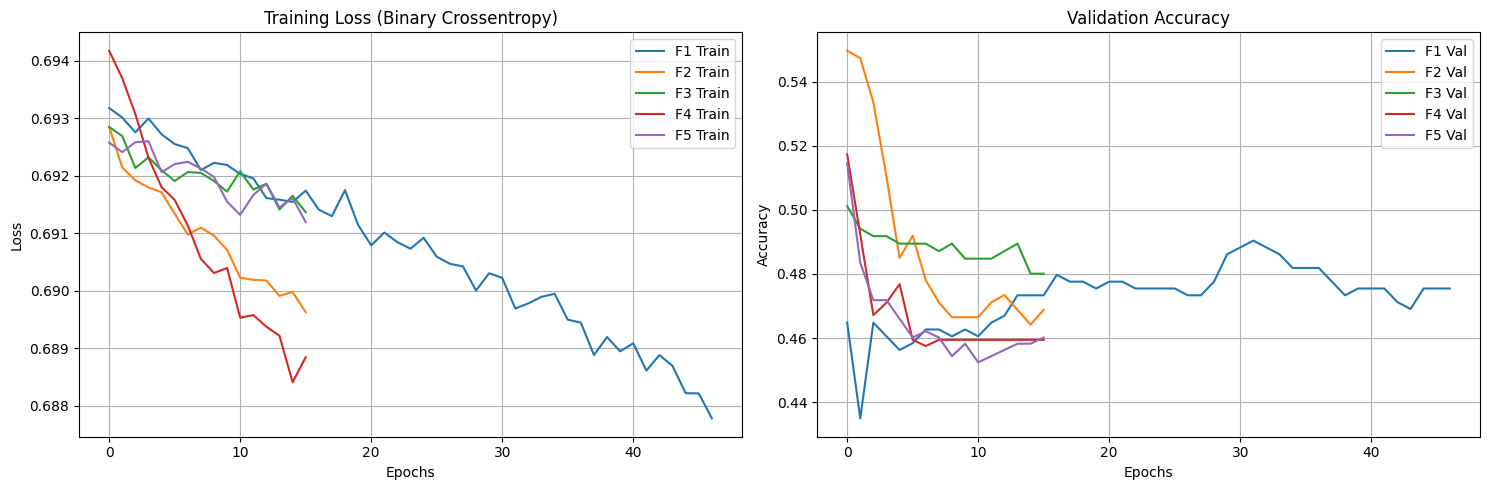


--- Overall Classification Report (All CV Validation Samples) ---
              precision    recall  f1-score   support

   Right (0)       0.53      0.44      0.48      1201
    Left (1)       0.51      0.59      0.54      1161

    accuracy                           0.51      2362
   macro avg       0.52      0.52      0.51      2362
weighted avg       0.52      0.51      0.51      2362



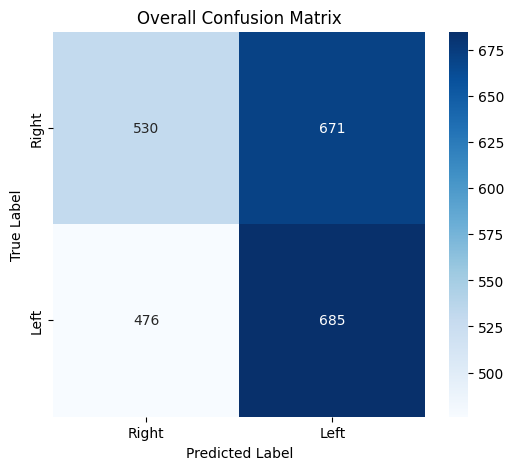


--- Performance by Age Category (Decision Prediction) ---
  Category: Younger (N=1416)
    Accuracy: 0.5028, Precision: 0.4823, Recall: 0.5236, F1: 0.5021, ROC AUC: 0.4948


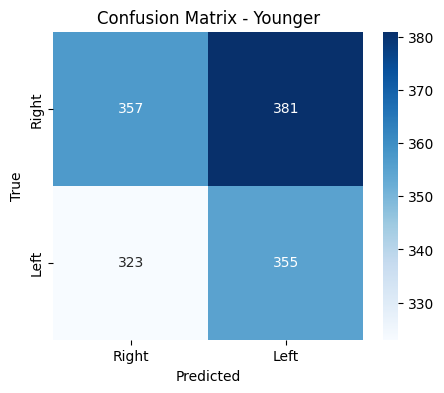

  Category: Older (N=946)
    Accuracy: 0.5317, Precision: 0.5323, Recall: 0.6832, F1: 0.5984, ROC AUC: 0.5455


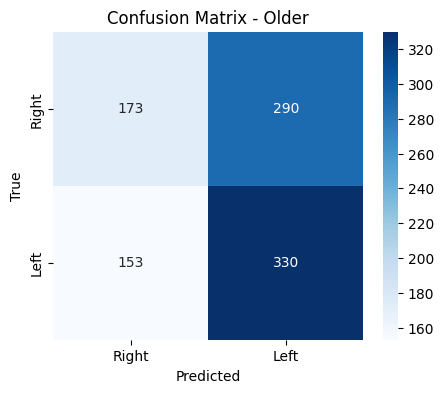

Script analysis section completed.


In [9]:
# Cell 8: Results Aggregation for Classification
if not fold_accuracies: 
    print("Skipping results: No training metrics.")
else:
    print("\n\n--- Cross-Validation Summary (Decision Prediction) ---")
    print(f"Avg Val Accuracy: {np.nanmean(fold_accuracies):.4f} (std: {np.nanstd(fold_accuracies):.4f})")
    print(f"Avg Val Precision: {np.nanmean(fold_precisions):.4f} (std: {np.nanstd(fold_precisions):.4f})")
    print(f"Avg Val Recall: {np.nanmean(fold_recalls):.4f} (std: {np.nanstd(fold_recalls):.4f})")
    print(f"Avg Val F1-Score: {np.nanmean(fold_f1s):.4f} (std: {np.nanstd(fold_f1s):.4f})")
    print(f"Avg Val ROC AUC: {np.nanmean(fold_roc_aucs):.4f} (std: {np.nanstd(fold_roc_aucs):.4f})")

    if fold_histories:
        plt.figure(figsize=(15, 5))
        plt.subplot(1,2,1); [plt.plot(h.history['loss'], label=f'F{i+1} Train') for i,h in enumerate(fold_histories) if h and 'loss' in h.history]
        plt.title('Training Loss (Binary Crossentropy)'); plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)
        plt.subplot(1,2,2); [plt.plot(h.history['val_accuracy'], label=f'F{i+1} Val') for i,h in enumerate(fold_histories) if h and 'val_accuracy' in h.history]
        plt.title('Validation Accuracy'); plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)
        plt.tight_layout(); plt.show()

    if all_y_true_val_folds:
        Y_true_all = np.concatenate(all_y_true_val_folds)
        Y_pred_proba_all = np.concatenate(all_y_pred_proba_val_folds)
        Y_pred_classes_all = (Y_pred_proba_all > 0.5).astype(int)
        age_cat_all = np.concatenate(all_age_categories_val_folds)

        print("\n--- Overall Classification Report (All CV Validation Samples) ---")
        print(classification_report(Y_true_all, Y_pred_classes_all, target_names=['Right (0)', 'Left (1)'], zero_division=0))
        
        cm = confusion_matrix(Y_true_all, Y_pred_classes_all)
        plt.figure(figsize=(6,5)); sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Right', 'Left'], yticklabels=['Right', 'Left'])
        plt.title('Overall Confusion Matrix'); plt.xlabel('Predicted Label'); plt.ylabel('True Label'); plt.show()

        print("\n--- Performance by Age Category (Decision Prediction) ---")
        for category in ['Younger', 'Older']:
            idx = (age_cat_all == category)
            if not np.any(idx): print(f'  {category}: No samples'); continue
            yt_cat, yp_cat_proba, yp_cat_class = Y_true_all[idx], Y_pred_proba_all[idx], Y_pred_classes_all[idx]
            
            if len(yt_cat) > 0:
                acc_cat = accuracy_score(yt_cat, yp_cat_class)
                prec_cat = precision_score(yt_cat, yp_cat_class, average='binary', zero_division=0)
                rec_cat = recall_score(yt_cat, yp_cat_class, average='binary', zero_division=0)
                f1_cat = f1_score(yt_cat, yp_cat_class, average='binary', zero_division=0)
                roc_auc_cat = roc_auc_score(yt_cat, yp_cat_proba) if len(np.unique(yt_cat)) > 1 else np.nan
                print(f'  Category: {category} (N={len(yt_cat)})')
                print(f'    Accuracy: {acc_cat:.4f}, Precision: {prec_cat:.4f}, Recall: {rec_cat:.4f}, F1: {f1_cat:.4f}, ROC AUC: {roc_auc_cat:.4f}')
                cm_cat = confusion_matrix(yt_cat, yp_cat_class)
                plt.figure(figsize=(5,4)); sns.heatmap(cm_cat, annot=True, fmt='d', cmap='Blues', xticklabels=['Right', 'Left'], yticklabels=['Right', 'Left'])
                plt.title(f'Confusion Matrix - {category}'); plt.xlabel('Predicted'); plt.ylabel('True'); plt.show()
            else:
                print(f'  {category}: No samples.')
print("Script analysis section completed.")